## Vedant Shirgaonkar
## D114 | D2-2
## EXP3(ML-II)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
X = np.array([0.5, 2.5])
Y = np.array([0.2, 0.9])

np.random.seed(42) 
initial_w = np.random.randn()
initial_b = np.random.randn()

learning_rate = 0.01
epochs = 100

print(f"Initial Weight (w): {initial_w:.4f}")
print(f"Initial Bias (b): {initial_b:.4f}")
print(f"Learning Rate (alpha): {learning_rate}")
print(f"Epochs: {epochs}")

Initial Weight (w): 0.4967
Initial Bias (b): -0.1383
Learning Rate (alpha): 0.01
Epochs: 100


In [5]:
w_sgd = initial_w
b_sgd = initial_b
loss_history_sgd = []
w_history_sgd = []
b_history_sgd = []

for epoch in range(epochs):
    for x_i, y_i in zip(X, Y):
        y_pred = w_sgd * x_i + b_sgd
        error = y_i - y_pred
        grad_w = -2 * x_i * error
        grad_b = -2 * error
        w_sgd -= learning_rate * grad_w
        b_sgd -= learning_rate * grad_b
        w_history_sgd.append(w_sgd)
        b_history_sgd.append(b_sgd)
        total_squared_error = np.sum((Y - (w_sgd * X + b_sgd))**2)
        mse = total_squared_error / len(Y)
        loss_history_sgd.append(mse)

print("--- SGD Final Results ---")
print(f"Final Weight (w): {w_sgd:.4f}")
print(f"Final Bias (b): {b_sgd:.4f}")
print(f"Final MSE: {loss_history_sgd[-1]:.4f}")

--- SGD Final Results ---
Final Weight (w): 0.3834
Final Bias (b): -0.0437
Final MSE: 0.0015


In [6]:
w_bgd = initial_w
b_bgd = initial_b
loss_history_bgd = []
w_history_bgd = []
b_history_bgd = []

for epoch in range(epochs):
    y_pred = w_bgd * X + b_bgd
    error = Y - y_pred
    grad_w = -2 * np.dot(X, error) / len(X)
    grad_b = -2 * np.sum(error) / len(X)
    w_bgd -= learning_rate * grad_w
    b_bgd -= learning_rate * grad_b
    w_history_bgd.append(w_bgd)
    b_history_bgd.append(b_bgd)
    total_squared_error = np.sum((Y - (w_bgd * X + b_sgd))**2)
    mse = total_squared_error / len(Y)
    loss_history_bgd.append(mse)

print("--- BGD Final Results ---")
print(f"Final Weight (w): {w_bgd:.4f}")
print(f"Final Bias (b): {b_bgd:.4f}")
print(f"Final MSE: {loss_history_bgd[-1]:.4f}")

--- BGD Final Results ---
Final Weight (w): 0.4073
Final Bias (b): -0.0897
Final MSE: 0.0036


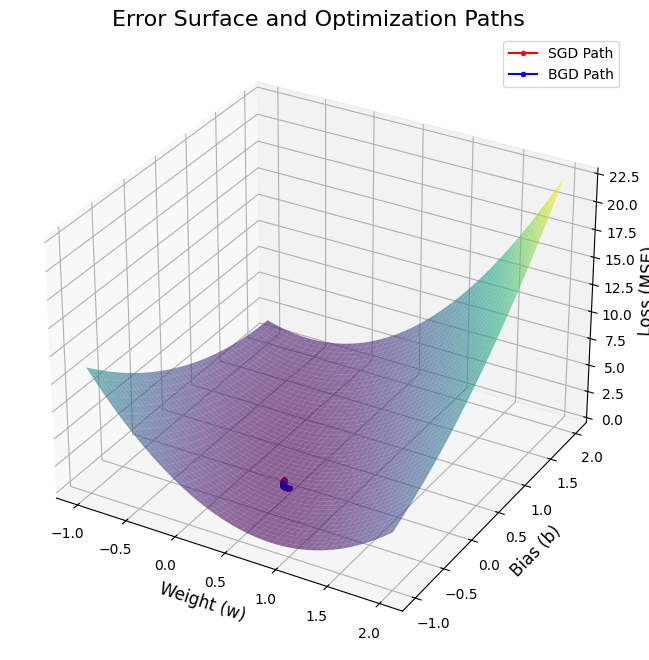

In [7]:
w_range = np.linspace(-1, 2, 50)
b_range = np.linspace(-1, 2, 50)
W, B = np.meshgrid(w_range, b_range)

Loss = np.zeros(W.shape)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_pred_grid = W[i, j] * X + B[i, j]
        Loss[i, j] = np.mean((Y - y_pred_grid)**2)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W, B, Loss, cmap='viridis', alpha=0.6, rstride=1, cstride=1, edgecolor='none')
ax.plot(w_history_sgd, b_history_sgd, loss_history_sgd, 'r-o', label='SGD Path', markersize=3)
ax.plot(w_history_bgd, b_history_bgd, loss_history_bgd, 'b-o', label='BGD Path', markersize=3)

ax.set_title('Error Surface and Optimization Paths', fontsize=16)
ax.set_xlabel('Weight (w)', fontsize=12)
ax.set_ylabel('Bias (b)', fontsize=12)
ax.set_zlabel('Loss (MSE)', fontsize=12)
ax.legend()
plt.show()

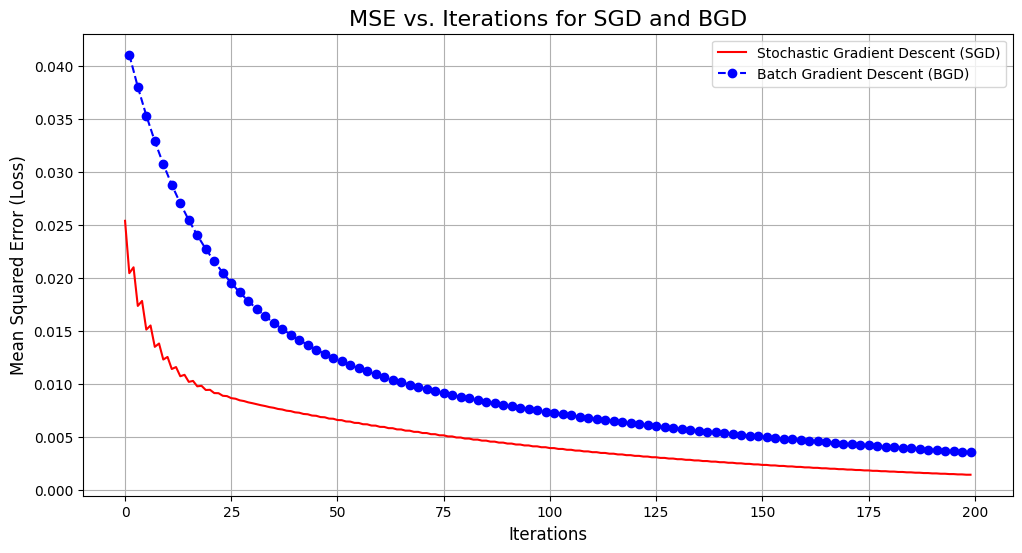

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(loss_history_sgd, label='Stochastic Gradient Descent (SGD)', color='red')
iterations_bgd = np.arange(len(X)-1, len(loss_history_sgd), len(X))
plt.plot(iterations_bgd, loss_history_bgd, label='Batch Gradient Descent (BGD)', color='blue', linestyle='--', marker='o')
plt.title('MSE vs. Iterations for SGD and BGD', fontsize=16)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

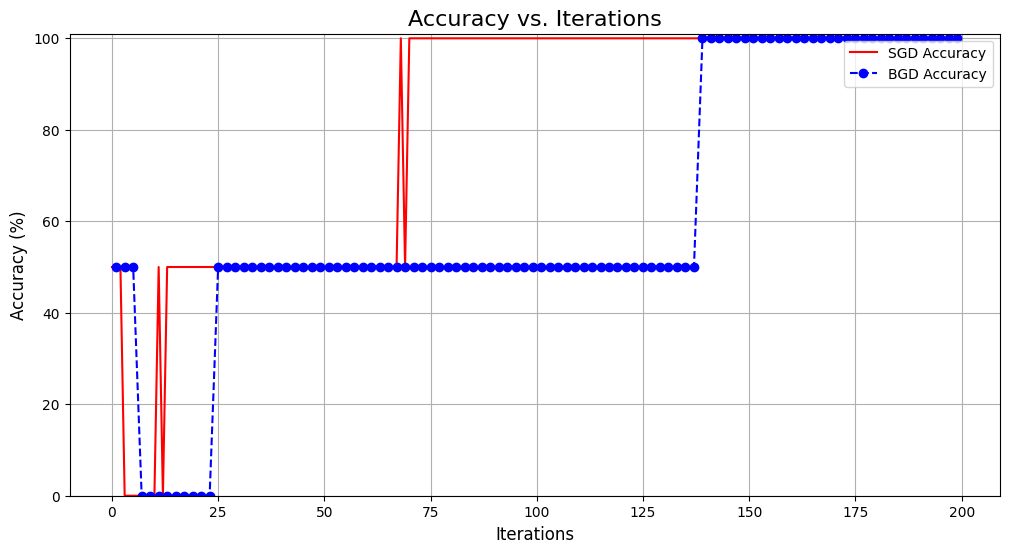

In [9]:
def calculate_accuracy(y_true, y_pred, tolerance=0.1):
    correct_predictions = np.sum(np.abs(y_true - y_pred) <= tolerance)
    return (correct_predictions / len(y_true)) * 100

accuracy_history_sgd = []
for w, b in zip(w_history_sgd, b_history_sgd):
    predictions = w * X + b
    accuracy_history_sgd.append(calculate_accuracy(Y, predictions))

accuracy_history_bgd = []
for w, b in zip(w_history_bgd, b_history_bgd):
    predictions = w * X + b
    accuracy_history_bgd.append(calculate_accuracy(Y, predictions))

plt.figure(figsize=(12, 6))
plt.plot(accuracy_history_sgd, label='SGD Accuracy', color='red')
plt.plot(iterations_bgd, accuracy_history_bgd, label='BGD Accuracy', color='blue', linestyle='--', marker='o')

plt.title('Accuracy vs. Iterations', fontsize=16)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True)
plt.ylim(0, 101)
plt.show()

### Implications:
The experiment highlights the fundamental trade-off between Batch Gradient Descent (BGD) and Stochastic Gradient Descent (SGD).

BGD is stable and precise, offering a smooth, direct path to minimizing error, but it's computationally slow as it must process the entire dataset for a single update.

Conversely, SGD is fast and efficient, updating after each data point, which is ideal for large datasets. However, this speed results in a noisier and more erratic path to the solution.

The choice between them depends on the specific application, balancing the need for speed against the desire for stability.